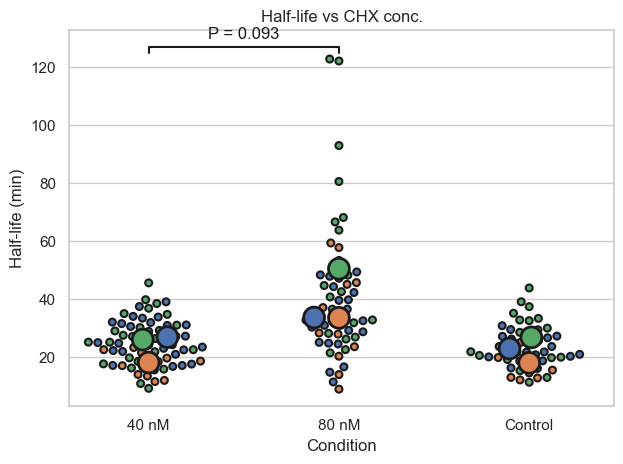

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats

# Load the dataset
# Replace this with your actual dataframe
# data = pd.read_csv("your_data.csv")
data = pd.read_csv('./decay_total', index_col=0)
sns.set(style="whitegrid")

# Calculate the average half-life for each sample
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

# Pivot table to prepare for paired t-test
ReplicateAvePivot = ReplicateAverages.pivot_table(columns='Condition', values='half-life', index="Exp")

# Ensure the pivot table has at least two conditions for statistical comparison
if ReplicateAvePivot.shape[1] >= 2:
    statistic, pvalue = scipy.stats.ttest_rel(
        ReplicateAvePivot.iloc[:, 0],  # First condition
        ReplicateAvePivot.iloc[:, 1]  # Second condition
    )
    P_value = str(float(round(pvalue, 3)))
else:
    P_value = "N/A (Not enough conditions for paired t-test)"

# Create the swarm plot
sns.swarmplot(x="Condition", y="half-life", hue="Exp", data=data, size=5, edgecolor="k", linewidth=1.5)
ax = sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages
)
ax.legend_.remove()

# Add significance annotation
x1, x2 = 0, 1  # Adjust these indices for your actual conditions
y, h, col = data['half-life'].max() + 2, 2, 'k'

# Ensure there are at least two conditions to plot the annotation
if ReplicateAvePivot.shape[1] >= 2:
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    plt.text((x1 + x2) * .5, y + h * 2, "P = " + P_value, ha='center', va='bottom', color=col)

# Final plot adjustments
plt.title("Half-life vs CHX conc.")
plt.xlabel("Condition")
plt.ylabel("Half-life (min)")
plt.tight_layout()
plt.show()


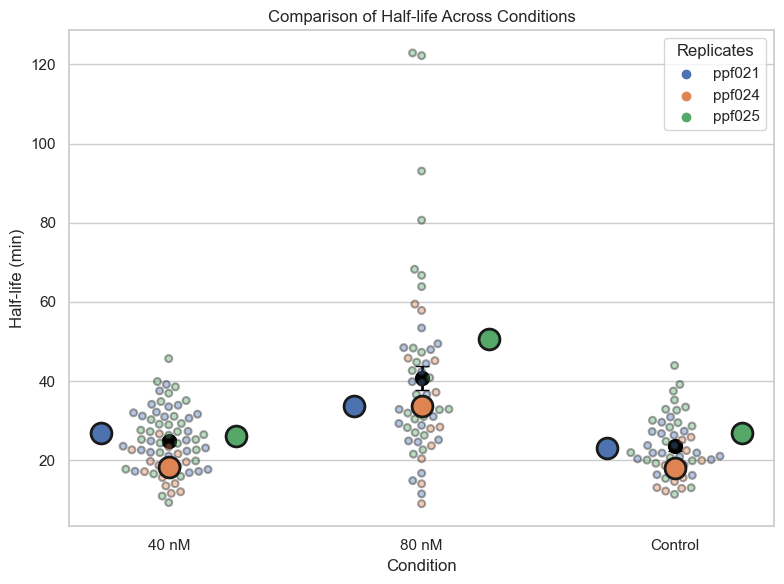

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats

# Example dataset
sns.set(style="whitegrid")

# Calculate the average half-life for each replicate
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

# Calculate mean and SEM for each condition
ConditionStats = data.groupby('Condition').agg(
    mean_half_life=('half-life', 'mean'),
    sem_half_life=('half-life', lambda x: scipy.stats.sem(x, nan_policy='omit'))
).reset_index()

# Create the swarm plot
plt.figure(figsize=(8, 6))

# Plot raw data with replicate-specific colors
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4
)

# Plot average of each replicate as a larger dot
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, dodge=True
)

# Overlay mean and SEM whiskers for each condition
for i, row in ConditionStats.iterrows():
    plt.errorbar(
        x=i, 
        y=row['mean_half_life'], 
        yerr=row['sem_half_life'], 
        fmt='o', 
        color='black',  # Color for mean points and whiskers
        capsize=5, 
        elinewidth=2, 
        markersize=10
    )

# Remove duplicate legend entries (for replicates and replicate averages)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Replicates")

# Final plot adjustments
plt.title("Comparison of Half-life Across Conditions")
plt.xlabel("Condition")
plt.ylabel("Half-life (min)")
plt.tight_layout()
plt.show()


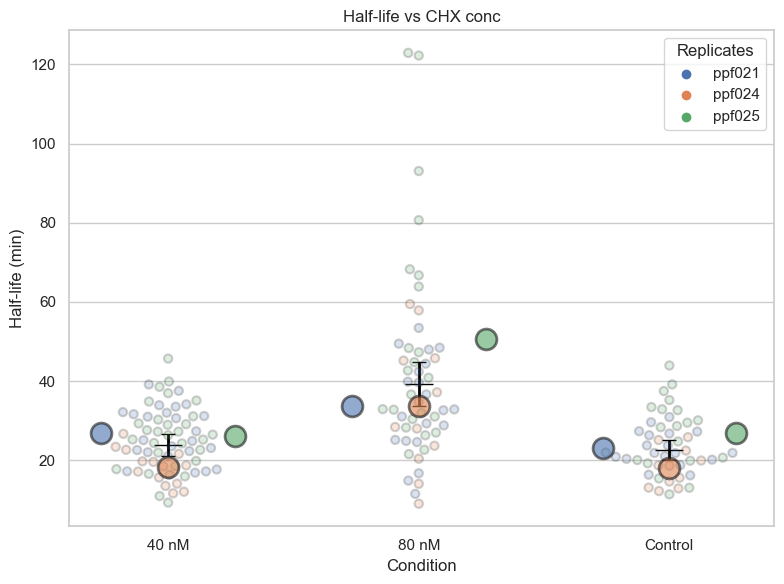

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import numpy as np

# Example dataset
sns.set(style="whitegrid")
# Calculate the average half-life for each replicate
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

# Calculate mean and SEM for each condition based on replicate averages
ConditionStats = ReplicateAverages.groupby('Condition').agg(
    mean_half_life=('half-life', 'mean'),
    sem_half_life=('half-life', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))  # SEM from replicate means
).reset_index()

# Create the swarm plot
plt.figure(figsize=(8, 6))

# Plot raw data with replicate-specific colors and transparency
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", data=data, size=6, edgecolor="k", linewidth=1.5, alpha=0.2
)

# Plot average of each replicate as a larger dot (no transparency for clarity)
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, dodge=True, alpha=0.6
)

# Overlay mean and SEM whiskers for each condition
for i, row in ConditionStats.iterrows():
    plt.errorbar(
        x=i, 
        y=row['mean_half_life'], 
        yerr=row['sem_half_life'], 
        fmt='_', 
        color='black',  # Color for mean points and whiskers
        capsize=5, 
        elinewidth=2, 
        markersize=20
    )

# Remove duplicate legend entries (for replicates and replicate averages)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Replicates")

# Final plot adjustments
plt.title("Half-life vs CHX conc")
plt.xlabel("Condition")
plt.ylabel("Half-life (min)")
plt.tight_layout()
plt.show()


In [16]:
ConditionStats

,Condition,mean_half_life,sem_half_life
0,40 nM,24.784298,0.955266
1,80 nM,40.739125,3.107885
2,Control,23.493317,1.059172


In [5]:
sns.set(style="whitegrid")

# Calculate the average half-life for each replicate
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

# Extract unique conditions
conditions = ReplicateAverages['Condition'].unique()

# Ensure the control group is correctly specified
if 'Control' not in conditions:
    raise ValueError("The 'Control' condition is missing from the data.")

# Prepare data for Dunnett's test
control_index = list(conditions).index('Control')  # Index of the control group
data_for_test = []

for condition in conditions:
    group_data = ReplicateAverages[ReplicateAverages['Condition'] == condition]['half-life'].values
    if len(group_data) > 0:
        data_for_test.append(group_data)

# Validate test groups
if len(data_for_test) <= control_index or len(data_for_test[control_index]) == 0:
    raise ValueError("The control group has insufficient or missing data for Dunnett's test.")

# Perform Dunnett's test
res = scipy.stats.dunnett(*data_for_test, control=control_index, alternative="two-sided")
dunnett_results = {conditions[i]: res.pvalue[i] for i in range(len(conditions)) if i != control_index}

# Calculate mean and SEM for each condition based on replicate averages
ConditionStats = ReplicateAverages.groupby('Condition').agg(
    mean_half_life=('half-life', 'mean'),
    sem_half_life=('half-life', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))  # SEM from replicate means
).reset_index()

# Create the swarm plot
plt.figure(figsize=(8, 6))

# Plot raw data with replicate-specific colors and transparency
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", data=data, size=8, edgecolor="k", linewidth=1.5, alpha=0.7
)

# Plot average of each replicate as a larger dot (no transparency for clarity)
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, dodge=True, alpha=1.0
)

# Overlay mean and SEM whiskers for each condition
for i, row in ConditionStats.iterrows():
    plt.errorbar(
        x=i, 
        y=row['mean_half_life'], 
        yerr=row['sem_half_life'], 
        fmt='o', 
        color='black',  # Color for mean points and whiskers
        capsize=5, 
        elinewidth=2, 
        markersize=10
    )

# Add Dunnett's test results as annotations
y_max = data['half-life'].max() + 2
for i, (condition, pvalue) in enumerate(dunnett_results.items(), start=1):
    annotation = f"P = {pvalue:.3f}"
    plt.text(i, y_max, annotation, ha='center', va='bottom', color='black')

# Remove duplicate legend entries (for replicates and replicate averages)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Replicates")

# Final plot adjustments
plt.title("Comparison of Half-life Across Conditions with Dunnett's Test")
plt.xlabel("Condition")
plt.ylabel("Half-life")
plt.tight_layout()
plt.show()

IndexError: tuple index out of range

In [9]:
dunnett_format = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

In [11]:
dunnett_format

,Condition,Exp,half-life
0,40 nM,ppf021,26.975460
1,40 nM,ppf024,18.197576
2,40 nM,ppf025,26.105171
3,80 nM,ppf021,33.716126
4,80 nM,ppf024,33.630398
5,80 nM,ppf025,50.554981
6,Control,ppf021,23.039730
7,Control,ppf024,18.085457
8,Control,ppf025,26.875869


In [15]:
dunnett_format = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})
dunnett_control = dunnett_format.loc[dunnett_format['Condition']=='Control','half-life']
dunnett_treatment = (dunnett_format.loc[dunnett_format['Condition']=='40 nM','half-life'], dunnett_format.loc[dunnett_format['Condition']=='80 nM','half-life'])
scipy.stats.dunnett(*dunnett_treatment, control=dunnett_control, alternative='two-sided', random_state=None)

In [19]:
dunnett_treatment = (dunnett_format.loc[dunnett_format['Condition']=='40 nM','half-life'], dunnett_format.loc[dunnett_format['Condition']=='80 nM','half-life'])

In [20]:
scipy.stats.dunnett(*dunnett_treatment, control=dunnett_control, alternative='two-sided', random_state=None)

DunnettResult(statistic=array([0.19739646, 3.00571172]), pvalue=array([0.97200304, 0.04220323]))

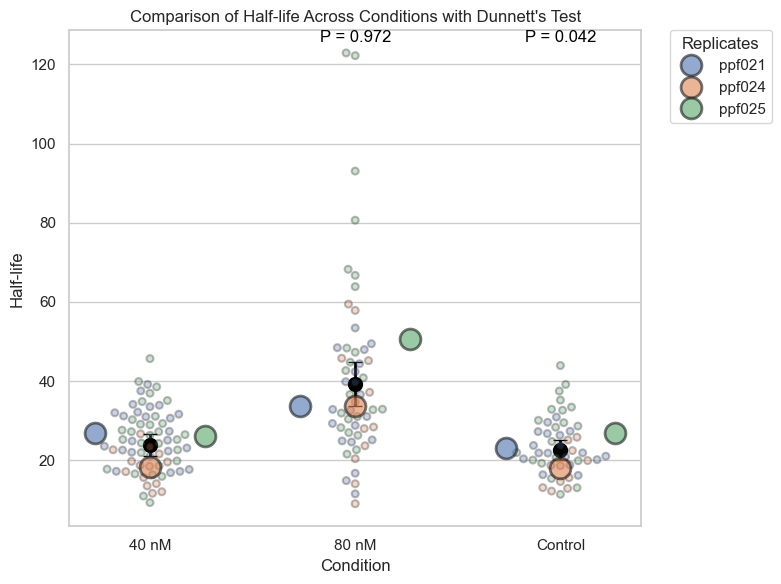

In [24]:
sns.set(style="whitegrid")

# Calculate the average half-life for each replicate
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

# Dunnett's test preparation and execution
dunnett_format = ReplicateAverages.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})
dunnett_control = dunnett_format.loc[dunnett_format['Condition'] == 'Control', 'half-life']
dunnett_treatment = (
    dunnett_format.loc[dunnett_format['Condition'] == '40 nM', 'half-life'], 
    dunnett_format.loc[dunnett_format['Condition'] == '80 nM', 'half-life']
)

# Perform Dunnett's test
dunnett_result = scipy.stats.dunnett(
    *dunnett_treatment, 
    control=dunnett_control, 
    alternative='two-sided', 
    random_state=None
)

# Extract p-values
dunnett_conditions = ['40 nM', '80 nM']
dunnett_pvalues = dict(zip(dunnett_conditions, dunnett_result.pvalue))

# Calculate mean and SEM for each condition based on replicate averages
ConditionStats = ReplicateAverages.groupby('Condition').agg(
    mean_half_life=('half-life', 'mean'),
    sem_half_life=('half-life', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))  # SEM from replicate means
).reset_index()

# Create the swarm plot
plt.figure(figsize=(8, 6))

# Plot raw data with replicate-specific colors and transparency
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.3
)

# Plot average of each replicate as a larger dot (no transparency for clarity)
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, dodge=True, alpha=0.6
)

# Overlay mean and SEM whiskers for each condition
for i, row in ConditionStats.iterrows():
    plt.errorbar(
        x=i, 
        y=row['mean_half_life'], 
        yerr=row['sem_half_life'], 
        fmt='o', 
        color='black',  # Color for mean points and whiskers
        capsize=5, 
        elinewidth=2, 
        markersize=10
    )

# Add Dunnett's test results as annotations
y_max = data['half-life'].max() + 2
condition_indices = {condition: i for i, condition in enumerate(['Control', '40 nM', '80 nM'])}
for condition, pvalue in dunnett_pvalues.items():
    i = condition_indices[condition]
    annotation = f"P = {pvalue:.3f}"
    plt.text(i, y_max, annotation, ha='center', va='bottom', color='black')

# Move the legend to the side
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(), 
    by_label.keys(), 
    title="Replicates", 
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

# Final plot adjustments
plt.title("Comparison of Half-life Across Conditions with Dunnett's Test")
plt.xlabel("Condition")
plt.ylabel("Half-life")
plt.tight_layout()
plt.show()

C:\Users\pperez\AppData\Local\Temp\14\ipykernel_45348\3399996639.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ConditionStats = ReplicateAverages.groupby('Condition').agg(


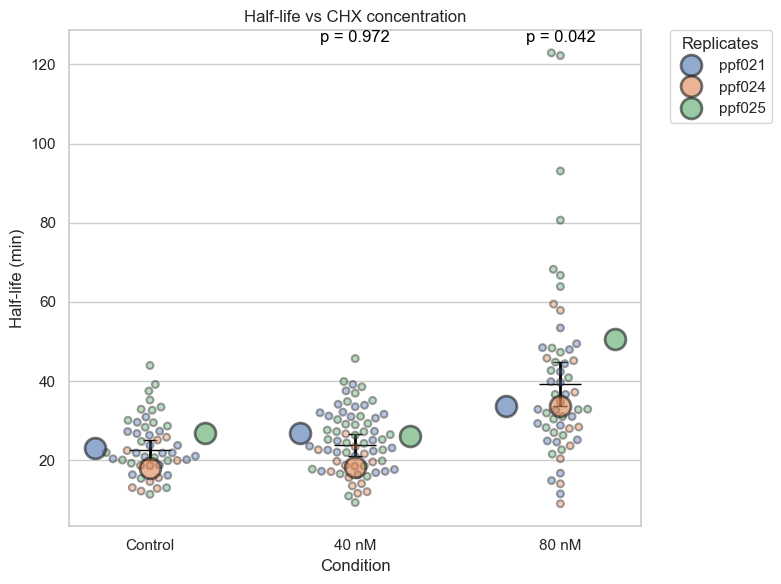

In [28]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import numpy as np

# Example dataset
data = pd.read_csv('./decay_total', index_col=0)

sns.set(style="whitegrid")

# Calculate the average half-life for each replicate
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})

# Dunnett's test preparation and execution
dunnett_format = ReplicateAverages.groupby(['Condition', 'Exp'], as_index=False).agg({'half-life': 'mean'})
dunnett_control = dunnett_format.loc[dunnett_format['Condition'] == 'Control', 'half-life']
dunnett_treatment = (
    dunnett_format.loc[dunnett_format['Condition'] == '40 nM', 'half-life'], 
    dunnett_format.loc[dunnett_format['Condition'] == '80 nM', 'half-life']
)

# Perform Dunnett's test
dunnett_result = scipy.stats.dunnett(
    *dunnett_treatment, 
    control=dunnett_control, 
    alternative='two-sided', 
    random_state=None
)

# Extract p-values
dunnett_conditions = ['40 nM', '80 nM']
dunnett_pvalues = dict(zip(dunnett_conditions, dunnett_result.pvalue))

# Reorder conditions to match desired plot order
data['Condition'] = pd.Categorical(
    data['Condition'], 
    categories=['Control', '40 nM', '80 nM'], 
    ordered=True
)
ReplicateAverages['Condition'] = pd.Categorical(
    ReplicateAverages['Condition'], 
    categories=['Control', '40 nM', '80 nM'], 
    ordered=True
)

# Calculate mean and SEM for each condition based on replicate averages
ConditionStats = ReplicateAverages.groupby('Condition').agg(
    mean_half_life=('half-life', 'mean'),
    sem_half_life=('half-life', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))  # SEM from replicate means
).reset_index()

# Create the swarm plot
plt.figure(figsize=(8, 6))

# Plot raw data with replicate-specific colors and transparency
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4
)

# Plot average of each replicate as a larger dot (no transparency for clarity)
sns.swarmplot(
    x="Condition", y="half-life", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, dodge=True, alpha=0.6
)

# Overlay mean and SEM whiskers for each condition
for i, row in ConditionStats.iterrows():
    plt.errorbar(
        x=i, 
        y=row['mean_half_life'], 
        yerr=row['sem_half_life'], 
        fmt='_', 
        color='black',  # Color for mean points and whiskers
        capsize=5, 
        elinewidth=2, 
        markersize=30
    )

# Add Dunnett's test results as annotations
y_max = data['half-life'].max() + 2
condition_indices = {condition: i for i, condition in enumerate(['Control', '40 nM', '80 nM'])}
for condition, pvalue in dunnett_pvalues.items():
    i = condition_indices[condition]
    annotation = f"p = {pvalue:.3f}"
    plt.text(i, y_max, annotation, ha='center', va='bottom', color='black')

# Move the legend to the side
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(), 
    by_label.keys(), 
    title="Replicates", 
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

# Final plot adjustments
plt.title("Half-life vs CHX concentration")
plt.xlabel("Condition")
plt.ylabel("Half-life (min)")
plt.tight_layout()
plt.savefig('./half-life_plot.png')
plt.show()


In [ ]:
ridges_averages = ridges_total.groupby(['Signal', 'Exp', 'Condition'], as_index=False).agg(
    {'periods':'mean'}
)

C:\Users\pperez\AppData\Local\Temp\14\ipykernel_45348\2938457644.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'periods': 'mean'})
C:\Users\pperez\AppData\Local\Temp\14\ipykernel_45348\2938457644.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dunnett_format = ReplicateAverages.groupby(['Condition', 'Exp'], as_index=False).agg({'periods': 'mean'})
C:\Users\pperez\AppData\Local\Temp\14\ipykernel_45348\2938457644.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

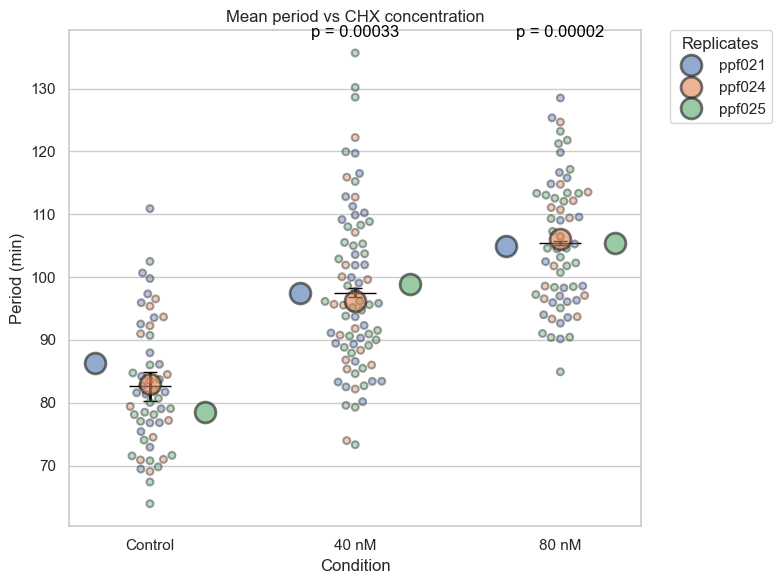

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import numpy as np

# Example dataset
data = ridges_averages

sns.set(style="whitegrid")

# Calculate the average half-life for each replicate
ReplicateAverages = data.groupby(['Condition', 'Exp'], as_index=False).agg({'periods': 'mean'})

# Dunnett's test preparation and execution
dunnett_format = ReplicateAverages.groupby(['Condition', 'Exp'], as_index=False).agg({'periods': 'mean'})
dunnett_control = dunnett_format.loc[dunnett_format['Condition'] == 'Control', 'periods']
dunnett_treatment = (
    dunnett_format.loc[dunnett_format['Condition'] == '40 nM', 'periods'], 
    dunnett_format.loc[dunnett_format['Condition'] == '80 nM', 'periods']
)

# Perform Dunnett's test
dunnett_result = scipy.stats.dunnett(
    *dunnett_treatment, 
    control=dunnett_control, 
    alternative='two-sided', 
    random_state=None
)

# Extract p-values
dunnett_conditions = ['40 nM', '80 nM']
dunnett_pvalues = dict(zip(dunnett_conditions, dunnett_result.pvalue))

# Reorder conditions to match desired plot order
data['Condition'] = pd.Categorical(
    data['Condition'], 
    categories=['Control', '40 nM', '80 nM'], 
    ordered=True
)
ReplicateAverages['Condition'] = pd.Categorical(
    ReplicateAverages['Condition'], 
    categories=['Control', '40 nM', '80 nM'], 
    ordered=True
)

# Calculate mean and SEM for each condition based on replicate averages
ConditionStats = ReplicateAverages.groupby('Condition').agg(
    mean_periods=('periods', 'mean'),
    sem_periods=('periods', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))  # SEM from replicate means
).reset_index()

# Create the swarm plot
plt.figure(figsize=(8, 6))

# Plot raw data with replicate-specific colors and transparency
sns.swarmplot(
    x="Condition", y="periods", hue="Exp", data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4
)

# Plot average of each replicate as a larger dot (no transparency for clarity)
sns.swarmplot(
    x="Condition", y="periods", hue="Exp", size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, dodge=True, alpha=0.6
)

# Overlay mean and SEM whiskers for each condition
for i, row in ConditionStats.iterrows():
    plt.errorbar(
        x=i, 
        y=row['mean_periods'], 
        yerr=row['sem_periods'], 
        fmt='_', 
        color='black',  # Color for mean points and whiskers
        capsize=5, 
        elinewidth=2, 
        markersize=30
    )

# Add Dunnett's test results as annotations
y_max = data['periods'].max() + 2
condition_indices = {condition: i for i, condition in enumerate(['Control', '40 nM', '80 nM'])}
for condition, pvalue in dunnett_pvalues.items():
    i = condition_indices[condition]
    annotation = f"p = {pvalue:.5f}"
    plt.text(i, y_max, annotation, ha='center', va='bottom', color='black')

# Move the legend to the side
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(), 
    by_label.keys(), 
    title="Replicates", 
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

# Final plot adjustments
plt.title("Mean period vs CHX concentration")
plt.xlabel("Condition")
plt.ylabel("Period (min)")
plt.tight_layout()
plt.savefig('./periods_plot.png')
plt.show()